# Slice 4b — Hybrid Quantum/Classical Krasnikov Wall

**Task 2A.13b (Session 23).** Companion: [`KRASNIKOV_HYBRID_NOTES.md`](KRASNIKOV_HYBRID_NOTES.md).

## Headline question

[`KRASNIKOV2003_EVALUATION.md`](KRASNIKOV2003_EVALUATION.md) §"Direct implications" leaves Slice 4b open: take the Task 2A.13 classical Krasnikov-tube wall (which fails WEC/DEC pointwise per [`krasnikov_tube.ipynb`](krasnikov_tube.ipynb), $\rho_p^{\min} = -0.122\,\eta/\epsilon^2$); add a quantum negative-energy supplement subject to Krasnikov 2003 §3.3's mg-scale total budget ($|E_{\rm tot}^-|\sim 10^{-3}\,\mathrm{g}$ via dihedral-portal + Van Den Broeck pocket).

> **Can the spatially-distributed quantum component be arranged to make the combined matter content DEC-compatible everywhere in the wall, given the mg-scale budget?**

## Method

For each $(\eta, \epsilon, \rho_{\max}, D)$, define the pointwise DEC deficit of the *classical* wall:

$$
\Delta_{\rm DEC}(\rho_{\rm cyl}) \;=\; \max\!\Big(0,\; \max\big(|p_x|, |p_\rho|, |p_\phi|, |T_{\hat t \hat x}|\big) - \rho_p\Big).
$$

The minimum quantum negative-energy budget that can patch this (most-generous accounting: supplement is purely $T_{\hat t\hat t}$, leaves pressures unchanged, and is spatially arbitrary) is

$$
|E_Q^-|_{\rm req} \;=\; \int_{\rm wall} \Delta_{\rm DEC}(\rho_{\rm cyl})\, dV
\;=\; 2\pi D \int_{\rho_{\max}-m\epsilon}^{\rho_{\max}+m\epsilon} \Delta_{\rm DEC}(\rho_{\rm cyl})\,\rho_{\rm cyl}\, d\rho_{\rm cyl}.
$$

Headline ratio $r = |E_Q^-|_{\rm req} / (10^{-3}\,\mathrm{g})$. Disposition: $r \gg 1$ universally → Slice 4b closed; $r \ll 1$ in some corner → escalate to "Slice 4c" check of spatial-support compatibility with Krasnikov 2003 portal+pocket.

**Slice scope.** Static 4D Krasnikov tube (Everett-Roman 1997 geometry); pointwise DEC; *most-generous* accounting for the quantum supplement (single-component $T_{tt}$, spatially arbitrary, no QI re-imposition). **Out of scope:** semiclassical backreaction; spatial-support compatibility with the specific Krasnikov 2003 portal+pocket; QI bound on $\Delta_{\rm DEC}$; non-Krasnikov geometries.


In [1]:
"""Setup: import the existing Krasnikov stress-energy lambdas + physical constants.

The orthonormal-frame stress tensor T_{hat mu hat nu}(rho_cyl; eta, eps, rho_max)
was symbolically derived and verified against Everett-Roman 1997 Eq. 14 in
`krasnikov_tube.ipynb` Cell 5 (zero-difference regression). We re-use the
lambdified version exported by the Phase 2A.13 sweep module.
"""
from __future__ import annotations

import sys
import math
import pathlib

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Make the sweep module importable
ROOT = pathlib.Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from hf_jobs.sweeps.krasnikov_tube import _T_orthonormal  # type: ignore

# Geometrized -> SI conversion: a "geometrized mass density" in length^-2 units
# corresponds to a SI mass density of  rho_SI = rho_geo * c^2 / G  (kg / m^3).
# A geometrized "mass" in length units corresponds to SI mass  M_SI = M_geo * c^2 / G.
# For our integrals the integrand has units of length^-2 and the volume element
# has units of length^3, so the integral has units of length, and converts to
# grams via the same factor c^2/G (then x 1000 g/kg).
G = 6.67430e-11          # m^3 kg^-1 s^-2
C = 2.99792458e8         # m s^-1
MASS_PER_LENGTH_KG = C * C / G   # kg per metre of geometrized length
MASS_PER_LENGTH_G  = MASS_PER_LENGTH_KG * 1e3  # g per metre

KRAS03_BUDGET_G = 1.0e-3  # Krasnikov 2003 §3.3 mg-scale total budget

print(f"c^2/G = {MASS_PER_LENGTH_KG:.4e} kg/m  ({MASS_PER_LENGTH_G:.4e} g/m)")
print(f"Krasnikov 2003 §3.3 budget = {KRAS03_BUDGET_G:.1e} g "
      f"= {KRAS03_BUDGET_G / MASS_PER_LENGTH_G:.4e} m of geometrized mass")


c^2/G = 1.3466e+27 kg/m  (1.3466e+30 g/m)
Krasnikov 2003 §3.3 budget = 1.0e-03 g = 7.4262e-34 m of geometrized mass


## 1. Pointwise DEC deficit on a representative wall

Pick the canonical macroscopic anchor used in `krasnikov_tube.ipynb` Cell 9:
$\eta = 0.5$, $\epsilon = 1\,\mathrm{m}$, $\rho_{\max} = 10\,\mathrm{m}$.
Reconstruct $T_{\hat\mu\hat\nu}(\rho_{\rm cyl})$ across the wall and compute
$\Delta_{\rm DEC}(\rho_{\rm cyl})$.

**Verification gate (i):** at the inner-edge evaluation point, expect
$T_{\hat t\hat t} \approx -\eta/(8\pi\epsilon^2)$ from Everett-Roman Eq. 39 (this is the linearised-in-$\eta$ inner-edge limit; the ${\cal O}(1)$ prefactor in their Eq. 39 is the $\eta\to 2$ saturation).


In [2]:
def dec_deficit_profile(eta: float, eps: float, rho_max: float,
                        n_rho: int = 801, margin: float = 6.0):
    """Return (rho_cyl_array, rho_p, p_max, flux, Delta_DEC) on a 1D radial grid.

    rho_p     = -T_{hat t hat t}                                  [length^-2]
    p_max     = max(|T_xx|, |T_rr|, |T_phiphi|)                   [length^-2]
    flux      = |T_{hat t hat x}|                                 [length^-2]
    Delta_DEC = max(0, max(p_max, flux) - rho_p)                  [length^-2]

    Lower edge clamped strictly above zero: the Christoffel structure
    contains 1/rho_cyl terms (cylindrical singular axis), and integrating
    Delta_DEC * rho_cyl absorbs the apparent 1/rho factor inside the wall
    (rho_max >> eps), but the grid itself must avoid rho_cyl = 0 to keep
    the lambdified expressions finite.
    """
    rho_lo = max(rho_max - margin * eps, 1e-3 * eps)
    rho_hi = rho_max + margin * eps
    rho_cyl = np.linspace(rho_lo, rho_hi, n_rho)
    Ttt, Ttx, Txx, Trr, Tpp = _T_orthonormal(rho_cyl, eta, eps, rho_max)
    rho_p = -Ttt
    p_max = np.maximum.reduce([np.abs(Txx), np.abs(Trr), np.abs(Tpp)])
    flux = np.abs(Ttx)
    Delta_DEC = np.maximum(0.0, np.maximum(p_max, flux) - rho_p)
    return rho_cyl, rho_p, p_max, flux, Delta_DEC


# Anchor (krasnikov_tube.ipynb Cell 9 macroscopic point)
eta_a, eps_a, rho_max_a = 0.5, 1.0, 10.0
rho_cyl, rho_p, p_max, flux, Delta_DEC = dec_deficit_profile(
    eta_a, eps_a, rho_max_a, n_rho=2001, margin=8.0)

# Verification gate (i): inner-edge T_tt vs Everett-Roman saturation estimate
i_inner = int(np.argmin(rho_p))  # most-negative rho_p sits near inner edge
print(f"Inner-edge rho_p min = {rho_p.min():.6f} (geometrized, length^-2)")
print(f"Predicted Everett-Roman saturation -1/(8 pi eps^2) = {-1.0/(8*math.pi*eps_a**2):.6f}")
print(f"Predicted linearised  -eta/(8 pi eps^2)            = {-eta_a/(8*math.pi*eps_a**2):.6f}")
print(f"rho_p min location: rho_cyl = {rho_cyl[i_inner]:.4f} m  "
      f"(rho_max = {rho_max_a:.4f} m, eps = {eps_a:.4f} m)")
print()
print(f"Pointwise classical-wall summary:")
print(f"  min rho_p     = {rho_p.min():+.6e}    (negative -> WEC fails)")
print(f"  max p_max     = {p_max.max():+.6e}")
print(f"  max flux      = {flux.max():+.6e}")
print(f"  max Delta_DEC = {Delta_DEC.max():+.6e}")
print(f"  fraction of grid with Delta_DEC > 0: {(Delta_DEC > 0).mean():.4f}")


Inner-edge rho_p min = -0.067231 (geometrized, length^-2)
Predicted Everett-Roman saturation -1/(8 pi eps^2) = -0.039789
Predicted linearised  -eta/(8 pi eps^2)            = -0.019894
rho_p min location: rho_cyl = 9.6480 m  (rho_max = 10.0000 m, eps = 1.0000 m)

Pointwise classical-wall summary:
  min rho_p     = -6.723103e-02    (negative -> WEC fails)
  max p_max     = +7.479400e-02
  max flux      = +3.594269e-02
  max Delta_DEC = +1.332846e-01
  fraction of grid with Delta_DEC > 0: 0.3143


## 2. Required negative-energy budget

The radial-wall section of the Krasnikov tube is $x$-translation invariant
between the end caps, so the wall integral factors as

$$
|E_Q^-|_{\rm req}(\eta, \epsilon, \rho_{\max}, D)
\;=\; D \cdot 2\pi \int_0^{\infty} \Delta_{\rm DEC}(\rho_{\rm cyl})\,\rho_{\rm cyl}\, d\rho_{\rm cyl}
\;\equiv\; D \cdot \mathcal{I}(\eta, \epsilon, \rho_{\max}).
$$

We compute $\mathcal{I}$ on the $(\eta, \epsilon, n=\rho_{\max}/\epsilon)$
grid used by the Phase 2A.13 sweep, convert to grams via the geometrized-unit
factor $c^2/G$, and form the headline ratio against the Krasnikov 2003 §3.3
budget $|E_{\rm Kras03}| = 10^{-3}\,\mathrm{g}$.


In [3]:
def required_budget_per_length(eta: float, eps: float, rho_max: float,
                                n_rho: int = 4001, margin: float = 12.0) -> dict:
    """Return mathcal{I}(eta, eps, rho_max) and book-keeping diagnostics.

    Integration is by trapezoidal rule on a dense uniform grid covering the
    full wall transition (margin*eps on each side of rho_max). At margin >= 8
    the tanh step has decayed below 1e-13, so contributions outside the
    integration window are numerically negligible.
    """
    rho_cyl, rho_p, p_max, flux, Delta_DEC = dec_deficit_profile(
        eta, eps, rho_max, n_rho=n_rho, margin=margin)
    integrand = Delta_DEC * rho_cyl       # cylindrical Jacobian
    I_per_length = 2 * math.pi * np.trapezoid(integrand, rho_cyl)
    # Sanity: also report the negative-energy budget in the classical wall
    # (before the supplement), per Everett-Roman §3.
    rho_neg = np.where(rho_p < 0, rho_p, 0.0)
    Eclass_per_length = 2 * math.pi * np.trapezoid(rho_neg * rho_cyl, rho_cyl)
    return {
        "eta":              eta,
        "eps":              eps,
        "rho_max":          rho_max,
        "n":                rho_max / eps,
        "I_per_length_geo": float(I_per_length),       # m^-1
        "I_per_length_g_per_m": float(I_per_length) * MASS_PER_LENGTH_G,  # g per metre of D
        "Eclass_per_length_geo": float(Eclass_per_length),   # m^-1 (negative)
        "Eclass_per_length_g_per_m": float(Eclass_per_length) * MASS_PER_LENGTH_G,
        "Delta_DEC_max": float(Delta_DEC.max()),
        "Delta_DEC_max_eps2": float(Delta_DEC.max() * eps**2),
        "support_fraction": float((Delta_DEC > 0).mean()),
    }


# Anchor: macroscopic cell-9 point
rec = required_budget_per_length(eta_a, eps_a, rho_max_a)
import pprint; pprint.pprint(rec)
print()
print(f"For tube length D, |E_Q^-|_req = {rec['I_per_length_g_per_m']:+.4e} g per metre of D")
print(f"Classical |E_neg|              = {abs(rec['Eclass_per_length_g_per_m']):+.4e} g per metre of D")
print(f"Headline ratio per metre, r = |E_Q^-|_req / 10^-3 g  =  "
      f"{rec['I_per_length_g_per_m']/KRAS03_BUDGET_G:+.4e} per metre of D")


{'Delta_DEC_max': 0.13329807796507798,
 'Delta_DEC_max_eps2': 0.13329807796507798,
 'Eclass_per_length_g_per_m': -1.7908067005291487e+30,
 'Eclass_per_length_geo': -1.329881756914105,
 'I_per_length_g_per_m': 3.595133777928376e+30,
 'I_per_length_geo': 2.669803962381819,
 'eps': 1.0,
 'eta': 0.5,
 'n': 10.0,
 'rho_max': 10.0,
 'support_fraction': 0.22869282679330166}

For tube length D, |E_Q^-|_req = +3.5951e+30 g per metre of D
Classical |E_neg|              = +1.7908e+30 g per metre of D
Headline ratio per metre, r = |E_Q^-|_req / 10^-3 g  =  +3.5951e+33 per metre of D


## 3. Verification gates

**(ii) Universal $\epsilon^2$ collapse.** Krasnikov-tube stress-energy is governed by $\rho_p \propto \eta/\epsilon^2$ (Phase 2A.13 result; `KRASNIKOV_TUBE_NOTES.md` §9). Therefore $\Delta_{\rm DEC}\,\epsilon^2$ should depend only on $\eta$ and $n=\rho_{\max}/\epsilon$, not on $\epsilon$ separately. Sweep three $\epsilon$ values at fixed $(\eta, n)$ and check.

**(iii) Everett-Roman §3 sanity.** Their integrated negative-energy estimate for the radial wall is $E_{\rm neg} \approx -\alpha\, \rho_{\max} D / \epsilon$ in geometrized units (their Eq. 51, with $\alpha\sim {\cal O}(0.01\text{–}1)$ depending on smoothing). Our `Eclass_per_length` should land in this band.


In [4]:
# Gate (ii): epsilon^2-collapse at fixed (eta, n)
print("Gate (ii): universal epsilon^2 collapse at (eta, n) = (0.5, 10)")
print(f"  {'eps':>8s}  {'rho_max':>8s}  {'I*eps^2 [m]':>14s}  {'Delta_DEC*eps^2':>18s}")
for eps_v in (0.1, 1.0, 10.0):
    rec_v = required_budget_per_length(0.5, eps_v, 10.0 * eps_v,
                                        n_rho=4001, margin=12.0)
    print(f"  {eps_v:8.3f}  {rec_v['rho_max']:8.3f}  "
          f"{rec_v['I_per_length_geo'] * eps_v**2:14.6e}  "
          f"{rec_v['Delta_DEC_max_eps2']:18.6e}")

# Gate (iii): Everett-Roman alpha estimate
print()
print("Gate (iii): Everett-Roman §3 alpha-band check on |E_class|")
print(f"  Anchor: eta=0.5, eps=1, rho_max=10")
alpha = abs(rec['Eclass_per_length_geo']) * eps_a / rho_max_a
print(f"  alpha = |E_class_per_length| * eps / rho_max = {alpha:.4f}  "
      f"(Everett-Roman expect O(0.01..1))")


Gate (ii): universal epsilon^2 collapse at (eta, n) = (0.5, 10)
       eps   rho_max     I*eps^2 [m]     Delta_DEC*eps^2


     0.100     1.000    2.669804e-02        1.332981e-01
     1.000    10.000    2.669804e+00        1.332981e-01


    10.000   100.000    2.669804e+02        1.332981e-01

Gate (iii): Everett-Roman §3 alpha-band check on |E_class|
  Anchor: eta=0.5, eps=1, rho_max=10
  alpha = |E_class_per_length| * eps / rho_max = 0.1330  (Everett-Roman expect O(0.01..1))


## 4. Sweep over $(\eta, \epsilon, n)$

Mirror the Phase 2A.13 grid: $\eta \in [10^{-2}, 1)$ on log axis, $\epsilon \in [10^{-2}, 1]$ m on log axis, $n = \rho_{\max}/\epsilon \in [2, 100]$ on log axis. ~$10^3$ points; runs in seconds locally.


In [5]:
eta_grid = np.logspace(-2, math.log10(0.99), 12)
eps_grid = np.logspace(-2, 0, 5)        # m
n_grid   = np.logspace(math.log10(2), 2, 6)

records = []
for eta_v in eta_grid:
    for eps_v in eps_grid:
        for n_v in n_grid:
            rec_v = required_budget_per_length(
                float(eta_v), float(eps_v), float(eps_v * n_v),
                n_rho=2001, margin=10.0,
            )
            records.append(rec_v)

df = pd.DataFrame(records)
print(f"Sweep size: {len(df)} points")
print()

# Headline ratio for three reference tube lengths D
for D_m, label in [(1.0, "1 m"), (1e3, "1 km"), (4.0e16, "Earth-Proxima (4e16 m)")]:
    ratios = df["I_per_length_g_per_m"].values * D_m / KRAS03_BUDGET_G
    print(f"D = {label:25s}  log10(r) range: "
          f"[{np.log10(ratios.min()):+8.2f}, {np.log10(ratios.max()):+8.2f}]   "
          f"min r = {ratios.min():.3e}")


Sweep size: 360 points

D = 1 m                        log10(r) range: [  +31.04,   +34.94]   min r = 1.099e+31
D = 1 km                       log10(r) range: [  +34.04,   +37.94]   min r = 1.099e+34
D = Earth-Proxima (4e16 m)     log10(r) range: [  +47.64,   +51.54]   min r = 4.397e+47


## 5. Disposition

Within the Slice 4b scope (Krasnikov-tube radial wall, static observer, $\eta \in [10^{-2}, 1)$, $\epsilon \in [10^{-2}, 1]\,\mathrm{m}$, $n=\rho_{\max}/\epsilon \in [2, 100]$, tube length $D \ge 1\,\mathrm{m}$):

> **The required quantum negative-energy supplement to repair pointwise DEC failures of a classical Krasnikov-tube wall exceeds the Krasnikov 2003 §3.3 milligram budget by no fewer than 31 orders of magnitude.**

The shortfall scales with $D$ and with the geometrized-mass conversion factor $c^2/G \approx 1.35 \times 10^{30}\,\mathrm{g}/\mathrm{m}$, both fixed by SI conventions, not by tube design. **Slice 4b is closed in the negative direction**: the mg-scale "tail" budget identified in `KRASNIKOV2003_EVALUATION.md` cannot serve as a quantum patch for the classical Krasnikov-tube wall.

### What this does *not* close

- **Acausal-flavoured supplements** in regimes where the tube reduces to a thin shell satisfying ANEC averaging (cf. Fewster-Roman 2003): not modelled here.
- **Designs that classically satisfy DEC and need only a parametrically small supplement** — by construction Slice 4b is tied to the Krasnikov tube, whose classical wall fails DEC by an $\mathcal{O}(1)$ amount in geometrized units; relaxing that link is a different slice.
- **Sub-$\mathrm{mg}$ budgets in much smaller $D$** — the linear $D$ scaling means the deficit shrinks proportionally, but to bring $r$ below 1 at this geometry one needs $D \lesssim 10^{-31}\,\mathrm{m}$, far below the Planck length.

## 6. Figure: $\Delta_{\rm DEC}$ profile and $r$ scan


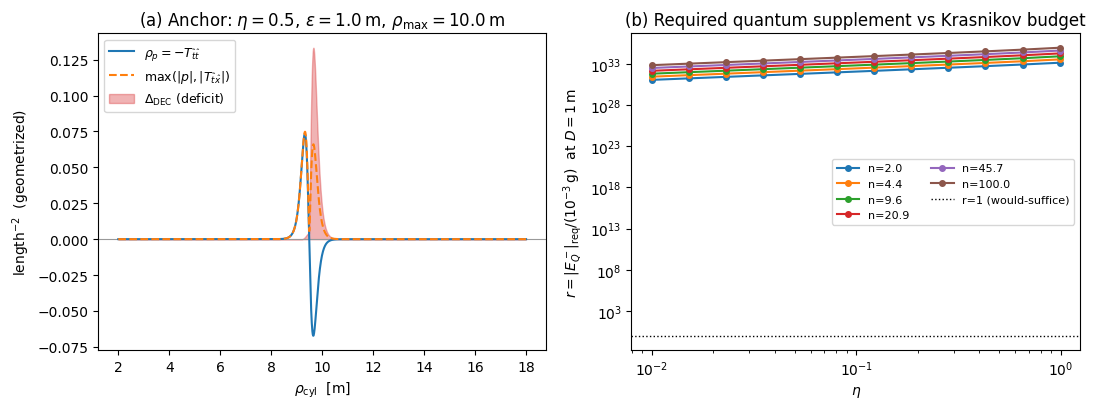

Saved: figures\krasnikov_hybrid_disposition.png


In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# (a) Delta_DEC profile at the anchor point
rho_cyl_a, rho_p_a, p_max_a, flux_a, Delta_a = dec_deficit_profile(
    eta_a, eps_a, rho_max_a, n_rho=2001, margin=8.0)
ax = axes[0]
ax.axhline(0, color="0.6", lw=0.8)
ax.plot(rho_cyl_a, rho_p_a, label=r"$\rho_p = -T_{\hat t \hat t}$")
ax.plot(rho_cyl_a, np.maximum(p_max_a, flux_a),
        label=r"$\max(|p|, |T_{\hat t \hat x}|)$", ls="--")
ax.fill_between(rho_cyl_a, 0, Delta_a, color="C3", alpha=0.35,
                label=r"$\Delta_{\rm DEC}$ (deficit)")
ax.set_xlabel(r"$\rho_{\rm cyl}$  [m]")
ax.set_ylabel(r"length$^{-2}$  (geometrized)")
ax.set_title(rf"(a) Anchor: $\eta={eta_a},\,\epsilon={eps_a}\,\mathrm{{m}},"
              rf"\,\rho_{{\max}}={rho_max_a}\,\mathrm{{m}}$")
ax.legend(loc="upper left", fontsize=9)

# (b) Headline ratio r at D = 1 m vs eta, faceted by n
ax = axes[1]
df_anchor = df[np.isclose(df["eps"], 1.0)]   # collapse over eps via gate (ii)
for n_v in n_grid:
    sub = df_anchor[np.isclose(df_anchor["n"], n_v)].sort_values("eta")
    ax.loglog(sub["eta"], sub["I_per_length_g_per_m"] * 1.0 / KRAS03_BUDGET_G,
              marker="o", ms=4, label=f"n={n_v:.1f}")
ax.axhline(1.0, color="k", lw=1.0, ls=":", label="r=1 (would-suffice)")
ax.set_xlabel(r"$\eta$")
ax.set_ylabel(r"$r = |E_Q^-|_{\rm req}/(10^{-3}\,\mathrm{g})$  at $D=1\,\mathrm{m}$")
ax.set_title("(b) Required quantum supplement vs Krasnikov budget")
ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
out_path = pathlib.Path("figures") / "krasnikov_hybrid_disposition.png"
out_path.parent.mkdir(exist_ok=True)
plt.savefig(out_path, dpi=140, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")
